# Fig1: HCT116 tree and Downsample Target vs Accuracy
- Goal is to compare different probe sets with different types of microsatellites

# Preprocesing
- Example command to run in terminal to generate results

```bash
#!/bin/bash

nextflow run ~/software/RETrace2/main.nf \
            --samplesheet 20210920_HCT116_2-6nt24k_samplesheet.csv \
            --output_dir results_2-6nt24k_500targets_minqual0 \
            --output_prefix 20210920_HCT116_CA2nt24k \
            --genome_base ~/Projects/GenomeDB \
            --genome hg38 \
            --target_bed /home/tcheng/software/RETrace2/resources/targets/hg38/RETrace.hg38.2-6nt.24000probes.bed \
            --min_qual 0 \
            --min_targets 500 \
            -profile docker \
            -resume \

nextflow run ~/software/RETrace2/main.nf \
            --samplesheet 20210920_HCT116_1nt12k_samplesheet.csv \
            --output_dir results_1nt12k_500targets_minqual0 \
            --output_prefix 20210920_HCT116_TW1nt12k \
            --genome_base ~/Projects/GenomeDB \
            --genome hg38 \
            --target_bed /home/tcheng/software/RETrace2/resources/targets/hg38/RETrace.hg38.1nt15-50bp.12472probes.bed \
            --min_targets 500 \
            --min_qual 0 \
            -profile docker \
            -resume \
```

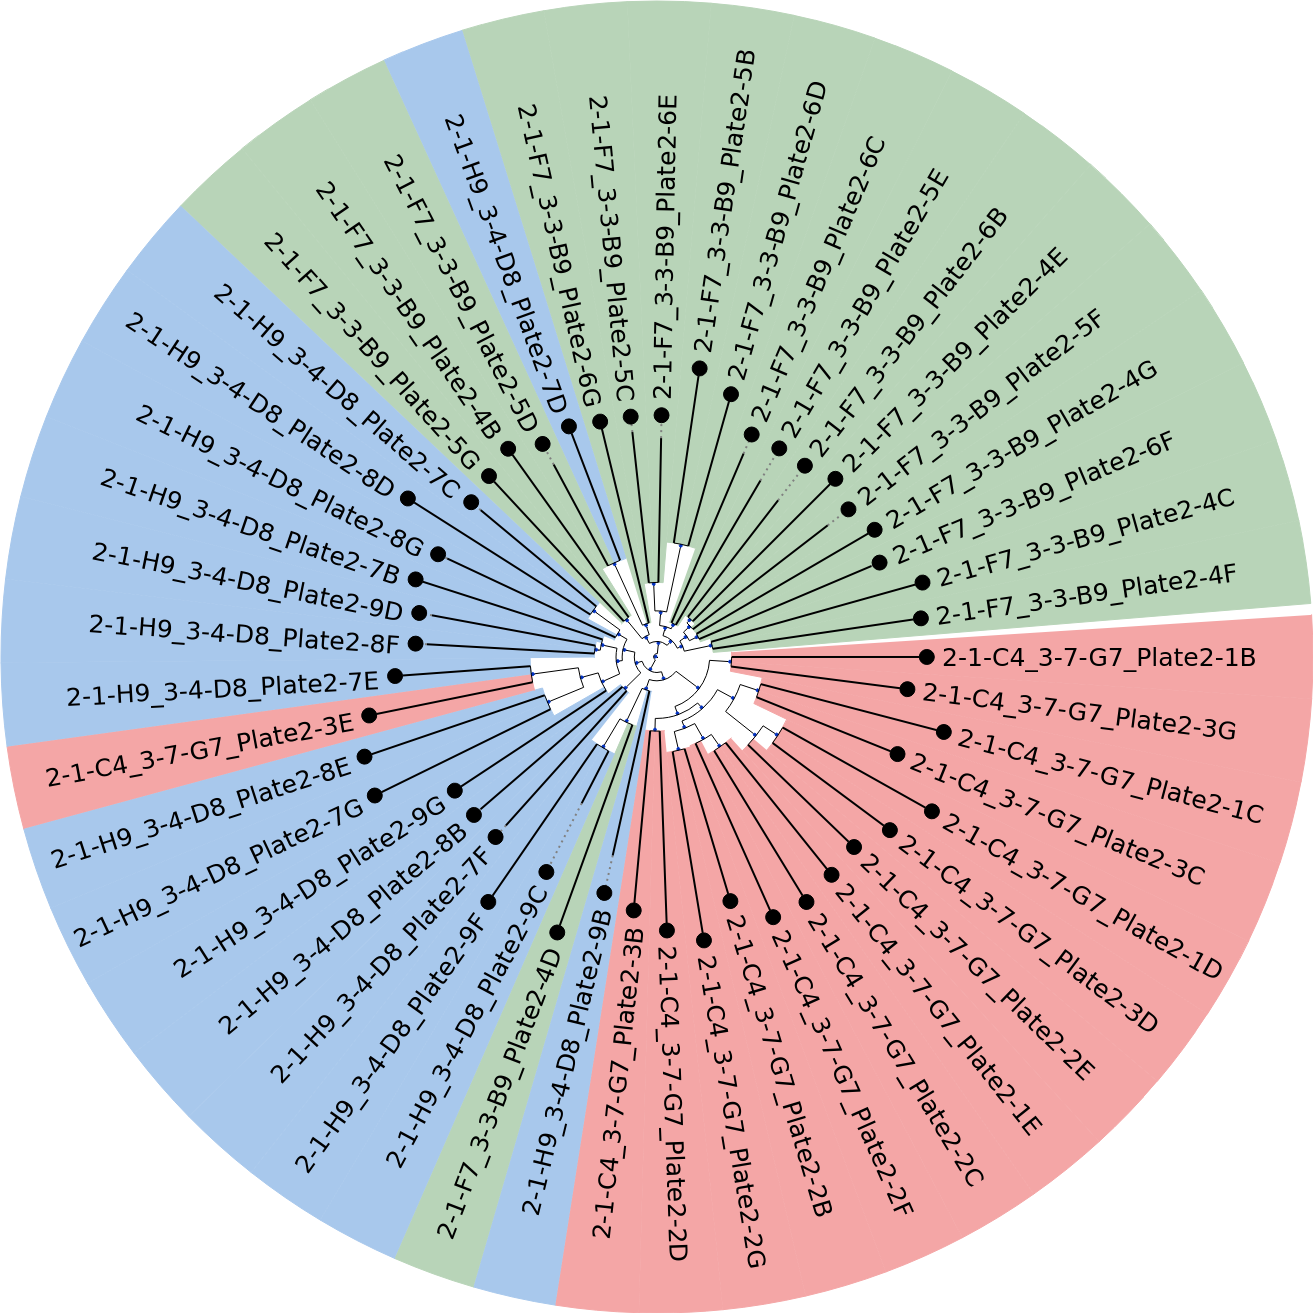

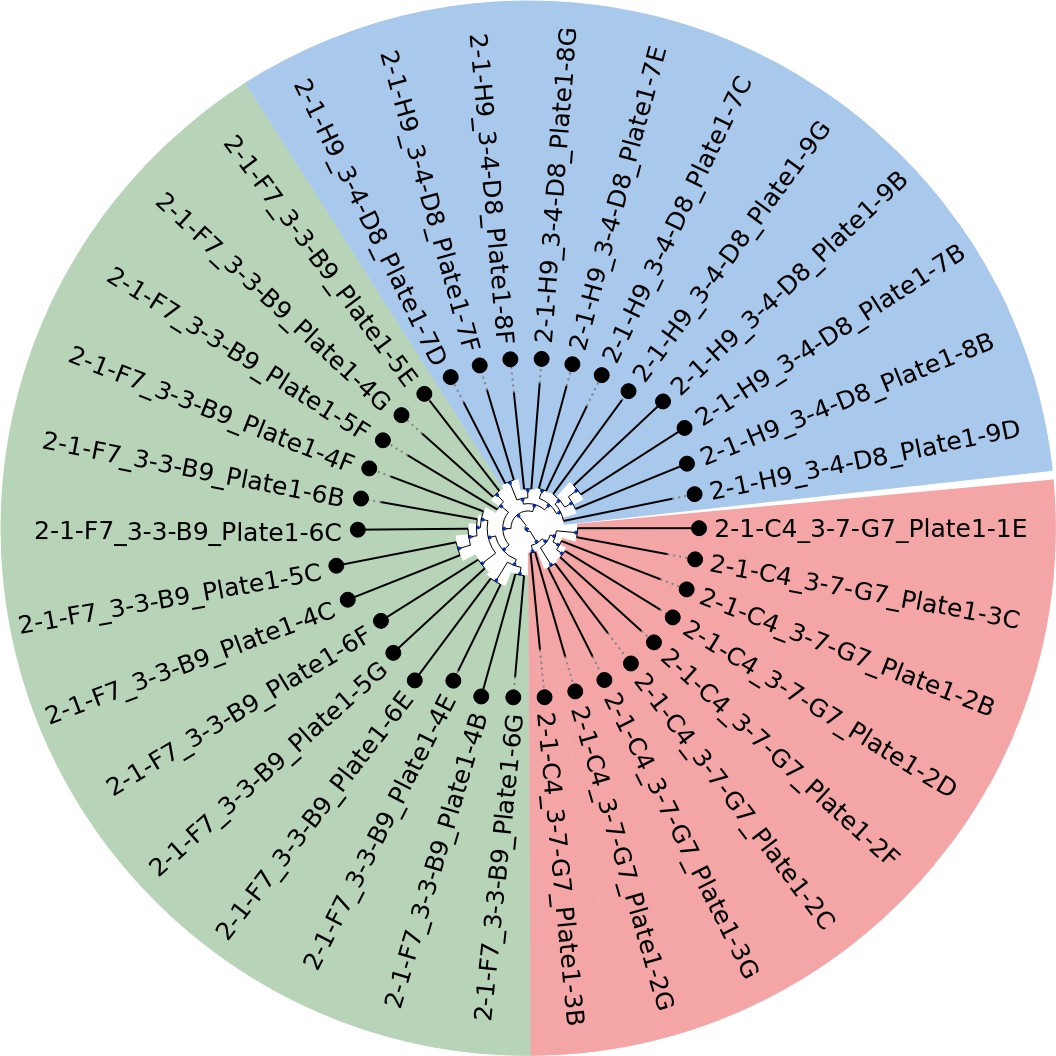

In [1]:
# specify --circular_tree option in nextflow command for circular tree output
from IPython.display import Image

# First plot for di- to hexanucleotide
display(Image("/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/20210920_HCT116_CA2nt24k_circular.viewPhylo.png"))

# Second plot for homopolymer
display(Image("/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/20210920_HCT116_TW1nt12k_circular.viewPhylo.png"))


## Downsample targets - 1nt12 library

```bash
#!/bin/bash

result_dir="/home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_1nt12k_500targets_minqual0"
output_dir="output_500targets_minqual0"
mkdir -p "$output_dir"
output_prefix="20210920_HCT116_1nt12k"
target_bed="/home/tcheng/software/RETrace2/resources/targets/hg38/RETrace.hg38.1nt15-50bp.12472probes.bed"
sample_sheet="/home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/20210920_HCT116_1nt12k_samplesheet.csv"

for n in {0..29} # number of random sample iterations
do
	for num_targets in {100..600..50} # number of targets to downsample to
	do
        echo -e "$num_targets\t$n\t$output_dir"

        python ~/software/RETrace2/scripts/downsampleTargets.py \
        --alleleDict $result_dir/hipstr/20210920_HCT116_1nt12k.alleleDict.pkl \
        --target_bed $target_bed \
        --numTargets $num_targets \
        --output_alleleDict ${output_dir}/${output_prefix}.alleleDict.$num_targets.$n.pkl \
        --output_sample_list ${output_dir}/${output_prefix}.sample_list.$num_targets.$n.txt \
        --random_seed $n

        python ~/software/RETrace2/modules/phylo/build_phylo.py \
        --alleleDict $output_dir/${output_prefix}.alleleDict.$num_targets.$n.pkl \
        --sample_list $output_dir/${output_prefix}.sample_list.$num_targets.$n.txt \
        --prefix $output_dir/${output_prefix}.HipSTR.$num_targets.$n \

        python /home/tcheng/software/RETrace2/scripts/evalPhylo.py\
        --samplesheet $sample_sheet \
        --exVivo_rootDist /home/tcheng/software/RETrace/Data/Cell_tree/HCT116_exvivo/exVivo.rootDist.v2.csv \
        --tree $output_dir/${output_prefix}.HipSTR.$num_targets.$n.buildPhylo.newick-original.txt \
        --prefix $output_dir/${output_prefix}.HipSTR.$num_targets.$n \
        --nproc 15 \
        --distDict $output_dir/${output_prefix}.HipSTR.$num_targets.$n.buildPhylo.distDict.pkl
        
        python ~/software/RETrace2/modules/phylo/view_phylo.py \
        --samplesheet $sample_sheet \
        --tree $output_dir/${output_prefix}.HipSTR.$num_targets.$n.buildPhylo.newick-original.txt \
        --prefix $output_dir/${output_prefix}.HipSTR.$num_targets.$n \
        --color_background
            
	done
done
```

# Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import glob
import re
import os
from scipy import stats

## Path

In [3]:
# create dictionary with key as probe set name and ouput directory
downsample_dir = '/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/downsample_targets'

data_dict = {'Homopolymner 15-50bp': f'{downsample_dir}/TW1nt12k_downsample/output_500targets_minqual0_minreads10',
             'Di- to Hexanucleotide': f'{downsample_dir}/CA2nt24k_downsample/output_500targets_minqual0_minreads10'}
             

## Read downsample results

In [4]:
def get_downsample_stat(eval_path):
    '''
    input: path to *evalPhylo.txt
    output: dictionary with n_target, accuracy, n_target_pair, n_sample
    '''
    
    # only include build path with eval path (some dont have eval path due to low n sample)
    build_path = eval_path.rstrip(".evalPhylo.txt") + ".buildPhylo.stats.txt"
    
    # get accuracy from evalPhylo.txt
    filename = os.path.basename(eval_path)
    n_target = int(filename.split(".")[2])
    df = pd.read_csv(eval_path, sep="\t", names=['accurate_n', 'total_n', 'accurate_rate'])
    all_accuracy = float(df.at["All_Distances", "accurate_rate"]) * 100
    
    # get n_target_pair and n_sample from buildphylo.stats.txt
    with open(build_path) as f:
        for line in f:
            if line.startswith('Number of Samples Analyzed'):
                n_sample = int(re.findall('[0-9]+', line)[0])
            if line.startswith('Avg targets shared per pair of cells'):
                n_target_pair = float(re.findall('[0-9]+\.[0-9]{1}', line)[0])
    
    return({'eval_path':eval_path, 'n_target':n_target, 'all_accuracy':all_accuracy, 'n_target_pair':n_target_pair, 'n_sample':n_sample})

In [5]:
df_list = []

for name, dir in data_dict.items():
    
    eval_path_list = sorted(glob.glob(f'{dir}/*evalPhylo.txt'))
    df = pd.DataFrame([get_downsample_stat(path) for path in eval_path_list])
    
    # add group name
    df['group'] = [name] * df.shape[0]
    df_list.append(df)
    
df_combined = pd.concat(df_list).reset_index(drop=True).set_index('eval_path')
df_combined.head()

,n_target,all_accuracy,n_target_pair,n_sample,group
eval_path,,,,,
/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/downsample_targets/TW1nt12k_downsample/output_500targets_minqual0_minreads10/20210920_HCT116_TW1nt12k.HipSTR.100.0.evalPhylo.txt,100,44.312046,10.9,34,Homopolymner 15-50bp
/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/downsample_targets/TW1nt12k_downsample/output_500targets_minqual0_minreads10/20210920_HCT116_TW1nt12k.HipSTR.100.1.evalPhylo.txt,100,34.667660,10.8,34,Homopolymner 15-50bp
/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/downsample_targets/TW1nt12k_downsample/output_500targets_minqual0_minreads10/20210920_HCT116_TW1nt12k.HipSTR.100.10.evalPhylo.txt,100,35.449637,11.3,34,Homopolymner 15-50bp
/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/downsample_targets/TW1nt12k_downsample/output_500targets_minqual0_minreads10/20210920_HCT116_TW1nt12k.HipSTR.100.11.evalPhylo.txt,100,30.888103,11.1,34,Homopolymner 15-50bp
/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/downsample_targets/TW1nt12k_downsample/output_500targets_minqual0_minreads10/20210920_HCT116_TW1nt12k.HipSTR.100.12.evalPhylo.txt,100,32.005213,11.3,34,Homopolymner 15-50bp


In [6]:
# Filter to only include data with minimum number of samples for accurate evaluation
df_combined_filtered = df_combined.query('n_sample >= 30')

## Plot
- sns lineplot shows mean and 95% confidence interval, random sample 30 times

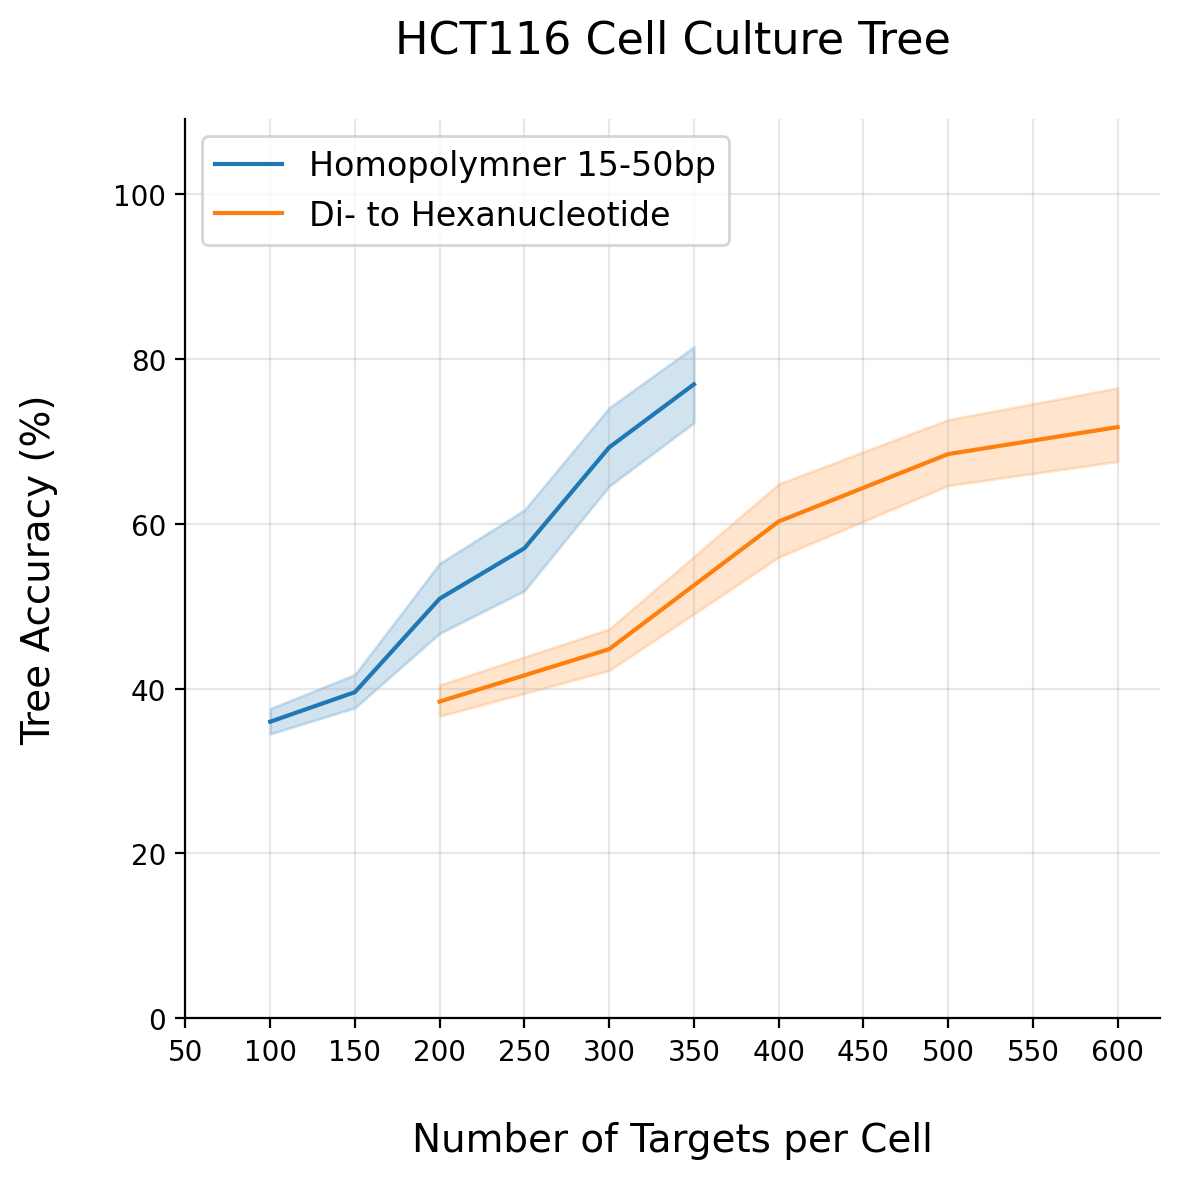

In [7]:
fig, ax = plt.subplots(figsize=(6,6), dpi=200)

sns.lineplot(data=df_combined_filtered, x='n_target', y='all_accuracy', hue='group')

ax.set_title('HCT116 Cell Culture Tree\n', fontsize=16)
ax.set_ylabel('Tree Accuracy (%)\n', fontsize=14)
ax.set_xlabel('\nNumber of Targets per Cell', fontsize=14)

ax.grid(True, alpha=0.3)
ax.set_ylim(0,109)
ax.set_xticks(np.arange(50,601,50))

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend(fontsize=12, loc="upper left")
plt.tight_layout()
plt.show()

## Regression analysis for more robust comparison

In [8]:
def calculate_regression_stats(df, group_name):
    """
    Calculate regression statistics for a specific group
    Returns: slope, intercept, r_squared, p_value, std_err
    """
    group_data = df[df['group'] == group_name]
    x = group_data['n_target'].values
    y = group_data['all_accuracy'].values
    
    # Linear regression using scipy
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2
    
    return {
        'group': group_name,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err,
        'n_points': len(x)
    }


In [9]:
# Calculate regression statistics for each group
regression_stats = []

for group in df_combined_filtered['group'].unique():
    stats_dict = calculate_regression_stats(df_combined_filtered, group)
    regression_stats.append(stats_dict)

print("Regression analysis completed for groups:", df_combined_filtered['group'].unique())


Regression analysis completed for groups: ['Homopolymner 15-50bp' 'Di- to Hexanucleotide']


In [10]:
# Display quantitative comparison table
regression_df = pd.DataFrame(regression_stats)
print("Quantitative Regression Analysis:")
print("="*60)
for _, row in regression_df.iterrows():
    print(f"\n{row['group']}:")
    print(f"  Slope: {row['slope']:.4f} (accuracy increase per target)")
    print(f"  R²: {row['r_squared']:.4f} (variance explained)")
    print(f"  P-value: {row['p_value']:.2e}")
    print(f"  Standard Error: {row['std_err']:.4f}")
    print(f"  Data Points: {row['n_points']}")


Quantitative Regression Analysis:

Homopolymner 15-50bp:
  Slope: 0.1712 (accuracy increase per target)
  R²: 0.6325 (variance explained)
  P-value: 1.52e-40
  Standard Error: 0.0098
  Data Points: 180

Di- to Hexanucleotide:
  Slope: 0.0902 (accuracy increase per target)
  R²: 0.5961 (variance explained)
  P-value: 6.22e-31
  Standard Error: 0.0061
  Data Points: 150


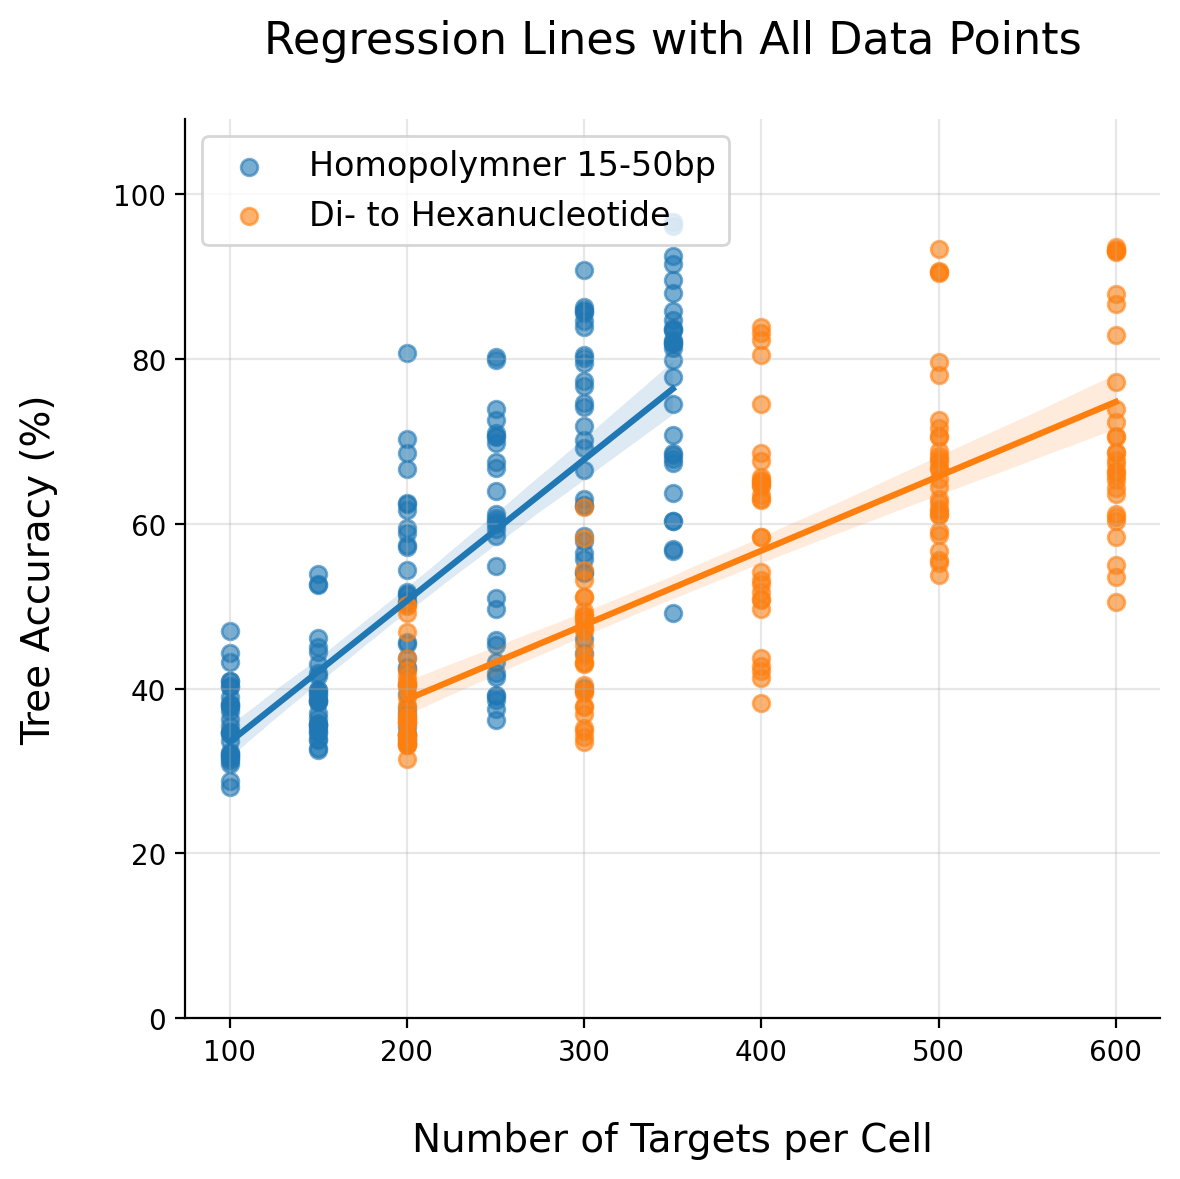

In [11]:
# Regression plot with all data points
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

for group in df_combined_filtered['group'].unique():
    group_data = df_combined_filtered[df_combined_filtered['group'] == group]
    sns.regplot(data=group_data, x='n_target', y='all_accuracy', 
                label=group, ax=ax, scatter_kws={'alpha':0.6})

ax.set_title('Regression Lines with All Data Points\n', fontsize=16)
ax.set_ylabel('Tree Accuracy (%)\n', fontsize=14)
ax.set_xlabel('\nNumber of Targets per Cell', fontsize=14)

ax.grid(True, alpha=0.3)
ax.set_ylim(0, 109)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend(fontsize=12, loc="upper left")
plt.tight_layout()
plt.show()

## Combined Plots

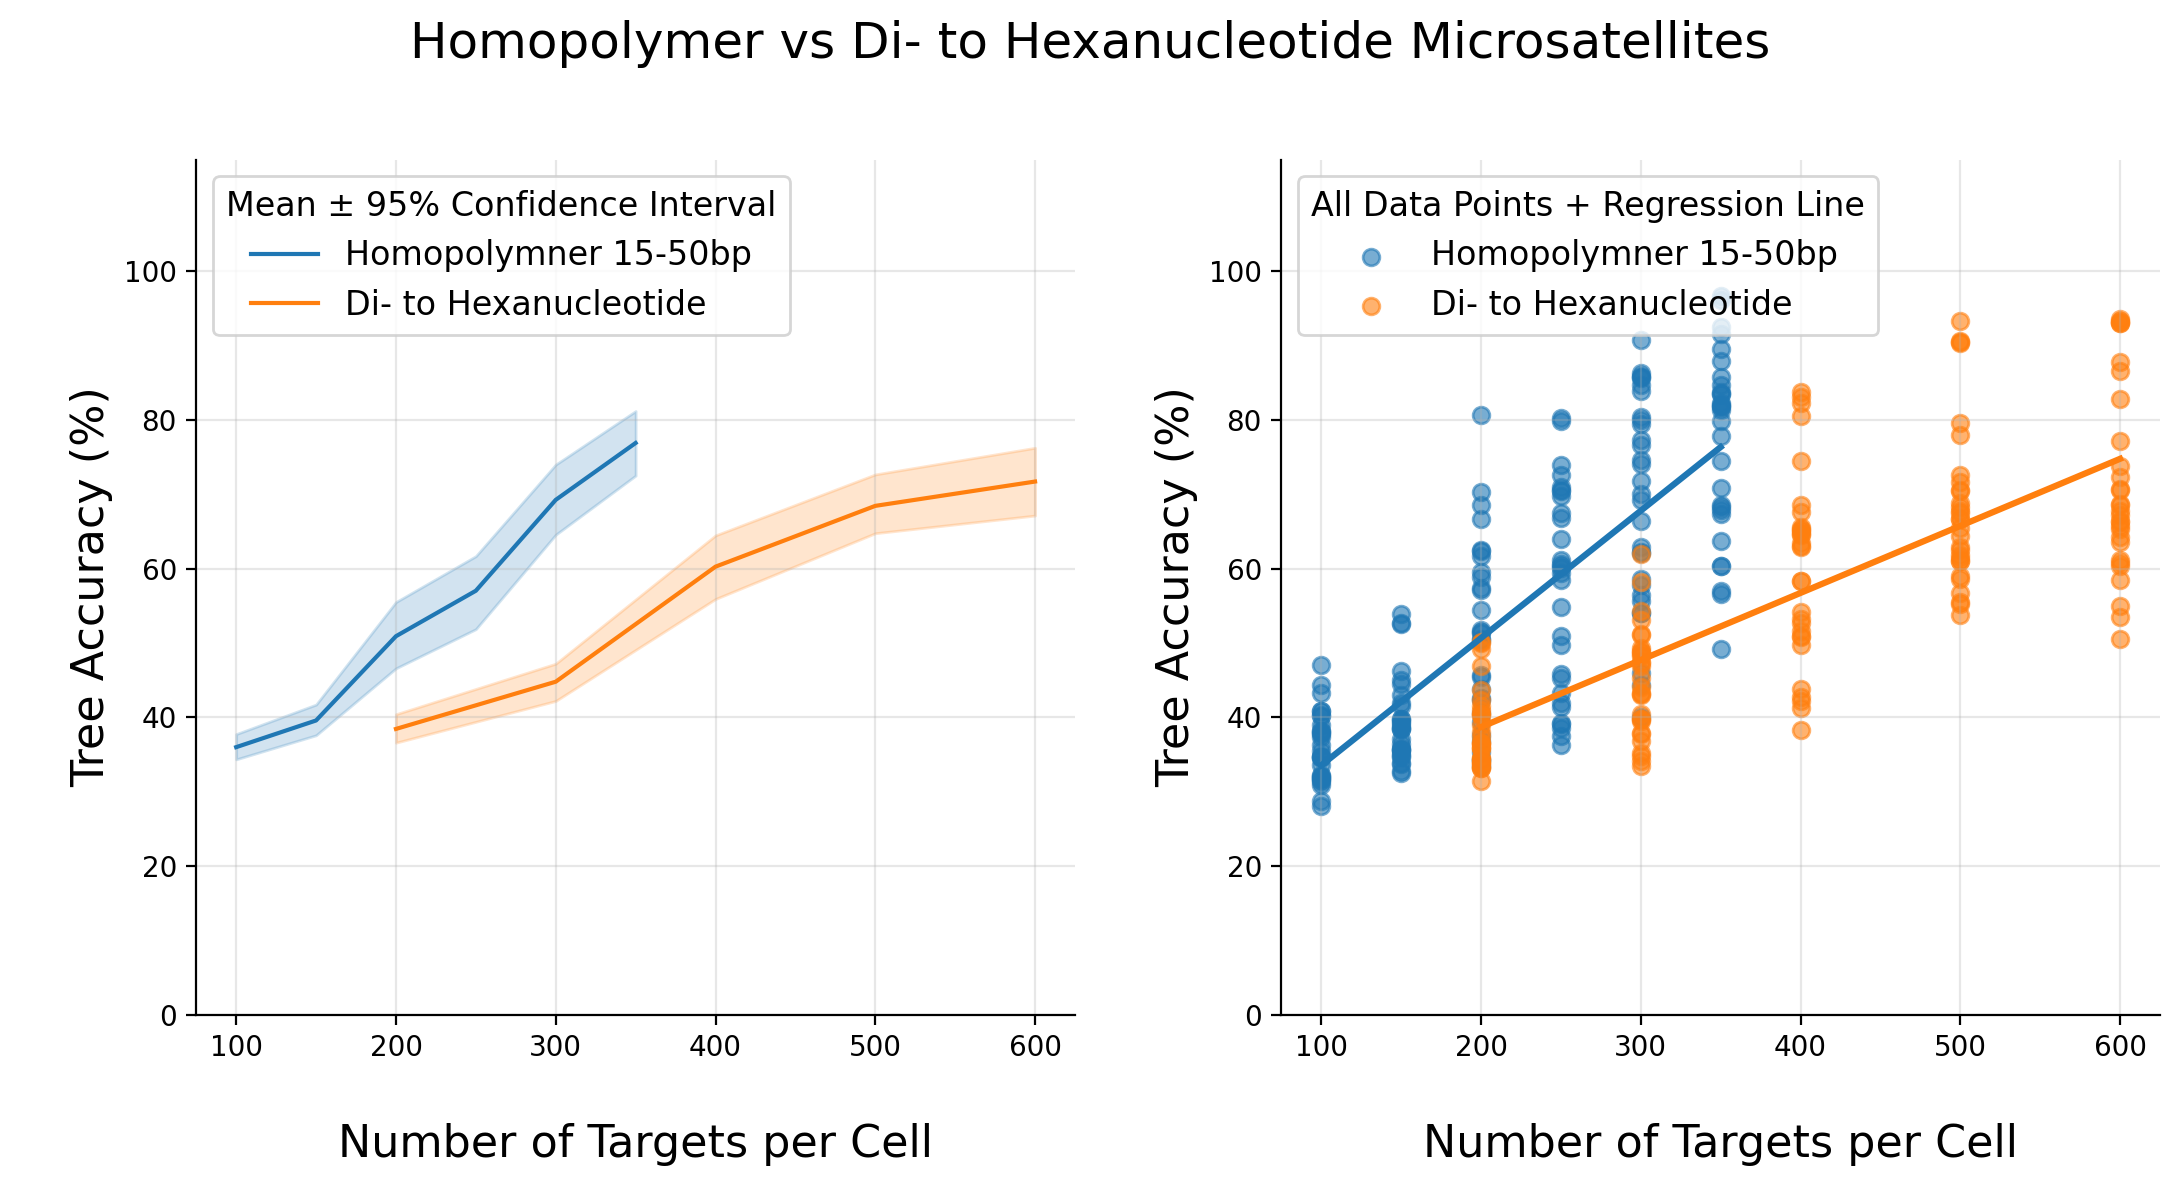

In [12]:
# Alternative: Using seaborn regplot for direct regression visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 6), dpi=200)
fig.suptitle('Homopolymer vs Di- to Hexanucleotide Microsatellites\n', fontsize=18)

# Left: Original lineplot (mean ± 95% CI)
sns.lineplot(data=df_combined_filtered, x='n_target', y='all_accuracy', hue='group', ax=axes[0])
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 115)
axes[0].legend(loc="upper left", fontsize=12, title="Mean ± 95% Confidence Interval", title_fontsize=12)

# Right: Regression plot with all data points
for group in df_combined_filtered['group'].unique():
    group_data = df_combined_filtered[df_combined_filtered['group'] == group]
    sns.regplot(data=group_data, x='n_target', y='all_accuracy', 
                label=group, ax=axes[1], scatter_kws={'alpha':0.6}, ci=None)

axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 115)
axes[1].legend(loc="upper left", fontsize=12, title="All Data Points + Regression Line", title_fontsize=12)

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('\nTree Accuracy (%)', fontsize=16)
    ax.set_xlabel('\nNumber of Targets per Cell', fontsize=16)

plt.tight_layout()
plt.savefig('Fig1_HCT116_1ntVs2nt_downsample_accuracy.pdf', dpi=200)
plt.show()